In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Load 2019 data for EDA (faster, focused)
df = pd.read_csv('../data/processed/delhi_2019_all_stations.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Add time features
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek  # 0=Monday
df['Season'] = df['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Summer', 4: 'Summer', 5: 'Summer',
    6: 'Monsoon', 7: 'Monsoon', 8: 'Monsoon', 9: 'Monsoon',
    10: 'Post-Monsoon', 11: 'Post-Monsoon'
})

print("Shape:", df.shape)
print("Stations:", df['Station'].nunique())
print("Date range:", df['Timestamp'].min(), "→", df['Timestamp'].max())
df.head(3)

Shape: (1366560, 33)
Stations: 37
Date range: 2019-01-01 00:00:00 → 2019-12-31 23:45:00


,Timestamp,PM25,PM10,NO,NO2,NOx,NH3,SO2,CO,Ozone,...,BP,VWS,Station,Year,Source_file,Hour,Day,Month,DayOfWeek,Season
0,2019-01-01 00:00:00,338.0,512.0,96.1,145.1,155.6,60.4,17.7,3.8,1.2,...,997.8,NaN,Alipur,2019,Raw_data_15Min_2019_site_5024_Alipur_Delhi_DPC...,0,1,1,1,Winter
1,2019-01-01 00:15:00,338.0,512.0,124.6,165.1,189.2,63.2,17.7,4.8,1.8,...,997.7,NaN,Alipur,2019,Raw_data_15Min_2019_site_5024_Alipur_Delhi_DPC...,0,1,1,1,Winter
2,2019-01-01 00:30:00,385.0,539.0,126.7,170.0,193.5,64.4,18.5,3.6,1.3,...,997.6,NaN,Alipur,2019,Raw_data_15Min_2019_site_5024_Alipur_Delhi_DPC...,0,1,1,1,Winter


In [2]:
pollutants = ['PM25', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 
              'CO', 'Ozone', 'Benzene', 'Toluene', 'Xylene']

stats = df[pollutants].describe().T
stats['skewness'] = df[pollutants].skew()
stats['kurtosis'] = df[pollutants].kurt()
stats = stats.round(2)

print("=== DESCRIPTIVE STATISTICS ===")
stats

=== DESCRIPTIVE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
PM25,1215921.0,109.31,104.94,0.04,41.00,74.00,140.00,1000.00,2.34,7.91
PM10,1113765.0,216.31,155.79,0.06,103.00,177.00,287.00,1000.00,1.48,2.69
NO,1188048.0,31.22,58.60,0.01,3.30,8.55,29.84,500.00,3.67,16.48
NO2,1203610.0,44.76,36.26,0.01,20.60,35.10,58.60,499.83,2.49,12.52
NOx,1206933.0,52.13,61.82,0.00,16.90,30.68,60.60,500.00,3.03,11.67
NH3,883576.0,36.43,22.29,0.01,22.77,32.00,44.80,495.30,3.21,28.52
SO2,950669.0,14.12,11.33,0.01,7.20,11.50,17.70,199.60,3.13,20.57
CO,1157557.0,1.37,1.15,0.00,0.69,1.10,1.70,44.79,3.13,30.69
Ozone,1159482.0,33.12,35.85,0.01,8.50,19.50,44.30,200.00,1.85,3.41
Benzene,969964.0,3.66,4.56,0.00,0.80,2.40,4.88,344.20,4.50,86.72


<Figure size 1400x600 with 0 Axes>

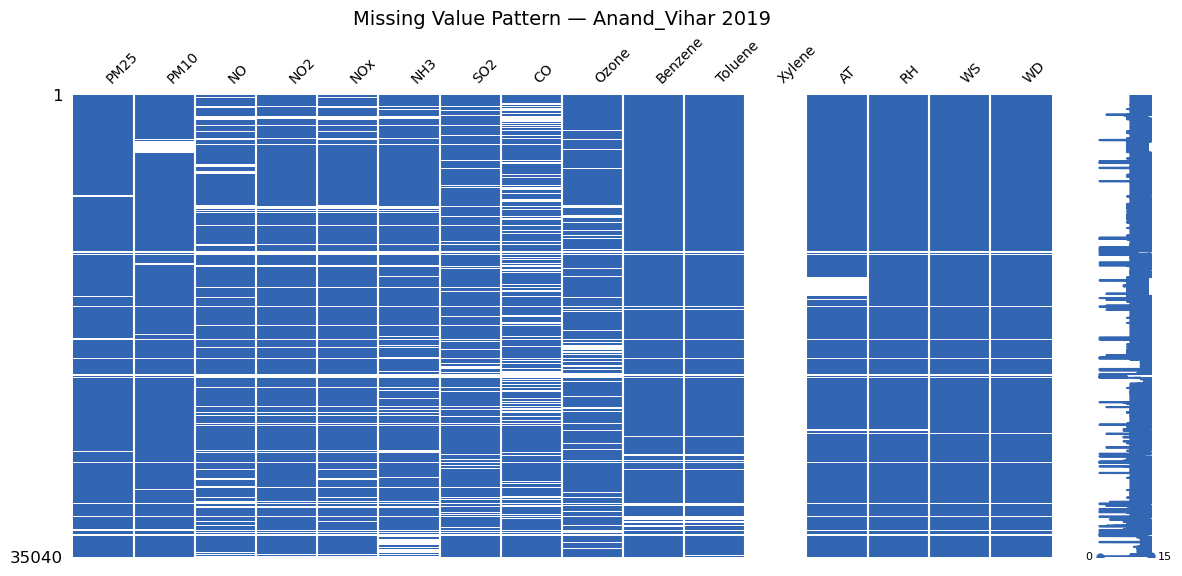

Saved!


In [3]:
# Pick one station for clean heatmap
station = 'Anand_Vihar'
df_station = df[df['Station'] == station].copy()

plt.figure(figsize=(14, 6))
msno.matrix(df_station[pollutants + ['AT', 'RH', 'WS', 'WD']], 
            figsize=(14, 6), fontsize=10, color=(0.2, 0.4, 0.7))
plt.title(f'Missing Value Pattern — {station} 2019', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/01_missing_values_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

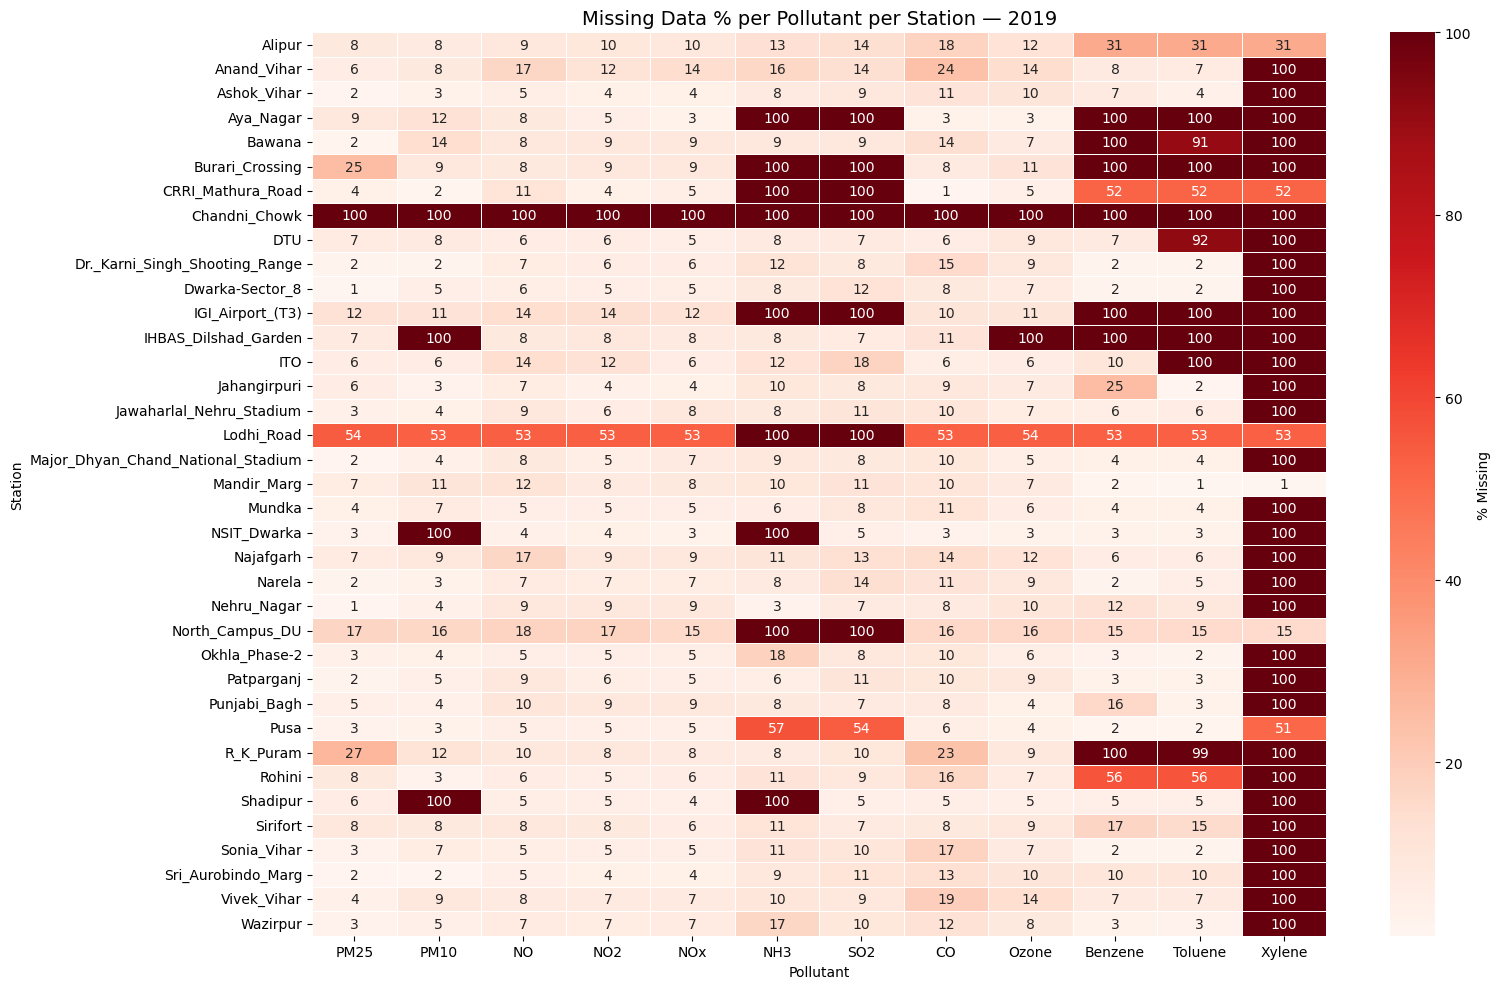

In [4]:
missing_pct = df.groupby('Station')[pollutants].apply(
    lambda x: (x.isnull().sum() / len(x) * 100).round(1)
)

plt.figure(figsize=(16, 10))
sns.heatmap(missing_pct, cmap='Reds', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': '% Missing'})
plt.title('Missing Data % per Pollutant per Station — 2019', fontsize=14)
plt.xlabel('Pollutant')
plt.ylabel('Station')
plt.tight_layout()
plt.savefig('../figures/02_missing_pct_station_variable.png', dpi=150, bbox_inches='tight')
plt.show()